## 1. Setup and Imports

In [1]:
# Kepler KOI Exoplanet Classification Benchmark
# Inter-Model Disagreement in Kepler Exoplanet Classification: A Leakage-Aware Benchmark
# Author: Andrii Mykuliak
# Dataset: NASA Kepler KOI Cumulative Table

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, GroupShuffleSplit, GroupKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve)
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier

RANDOM_STATE = 42
print("Imports ready")

Imports ready


In [2]:
# Software versions — for reproducibility
import sys, sklearn, xgboost, numpy, pandas, scipy

print("=== Software Environment ===")
print(f"Python:       {sys.version.split()[0]}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost:      {xgboost.__version__}")
print(f"numpy:        {numpy.__version__}")
print(f"pandas:       {pandas.__version__}")
print(f"scipy:        {scipy.__version__}")
print(f"\nRandom seed:  RANDOM_STATE = 42")
print(f"Stability seeds: [0, 7, 21, 42, 99]")
print(f"Dataset:      NASA KOI cumulative.csv (January 2025)")

=== Software Environment ===
Python:       3.13.9
scikit-learn: 1.7.2
xgboost:      3.2.0
numpy:        2.3.5
pandas:       2.3.3
scipy:        1.16.3

Random seed:  RANDOM_STATE = 42
Stability seeds: [0, 7, 21, 42, 99]
Dataset:      NASA KOI cumulative.csv (January 2025)


## 2. Data Loading

In [3]:
# Load dataset
df = pd.read_csv('cumulative.csv', comment='#')

print(f"Dataset shape: {df.shape}")
print(f"\nkoi_disposition distribution:")
print(df['koi_disposition'].value_counts())

Dataset shape: (9564, 49)

koi_disposition distribution:
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64


## 3. Preprocessing and Feature Selection

In [4]:
# Keep only CONFIRMED and FALSE POSITIVE
df = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])]

# Physical transit and stellar features only
# Excluded: identifiers, measurement errors,
# diagnostic flags (koi_fpflag_*) and koi_score (data leakage)
features = [
    'koi_period',
    'koi_impact',
    'koi_duration',
    'koi_depth',
    'koi_prad',
    'koi_teq',
    'koi_model_snr',
    'koi_steff',
    'koi_slogg',
    'koi_srad',
    'koi_insol',
    'koi_kepmag'
]

target = 'koi_disposition'

# Select features only — imputation is deferred until after train/test split
# to prevent data leakage (median must be computed on training set only)
df_model = df[features + [target, 'kepid']].copy()

# Encode target variable
df_model['target'] = (df_model[target] == 'CONFIRMED').astype(int)

print(f"Rows after filtering: {df_model.shape[0]}")
print(f"Features: {len(features)}")
print(f"Missing values (before imputation): {df_model[features].isnull().sum().sum()}")
print(f"\nClass distribution:")
print(df_model[target].value_counts())

Rows after filtering: 7585
Features: 12
Missing values (before imputation): 2292

Class distribution:
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
Name: count, dtype: int64


In [5]:
# Missing values — full dataset (9564 rows, before filtering)
df_orig = pd.read_csv('cumulative.csv', comment='#')

missing = df_orig[features].isnull().sum()
pct = (missing / len(df_orig) * 100).round(2)

pd.DataFrame({'Missing (n)': missing, 'Missing (%)': pct})

,Missing (n),Missing (%)
koi_period,0,0.00
koi_impact,363,3.80
koi_duration,0,0.00
koi_depth,363,3.80
koi_prad,363,3.80
koi_teq,363,3.80
koi_model_snr,363,3.80
koi_steff,363,3.80
koi_slogg,363,3.80
koi_srad,363,3.80


## 4. Train/Test Split — Group-Aware (GroupShuffleSplit by kepid)

In [6]:
X      = df_model[features]
y      = df_model['target']
groups = df_model['kepid']  # group variable — one star may have multiple KOIs

# Group-aware 80/20 split: no kepid appears in both train and test
# Prevents leakage of stellar parameters shared across KOIs of the same star
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# Verify: zero kepid overlap between train and test
assert len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])) == 0, \
    "kepid leakage detected!"

# Leakage-aware imputation: compute median on training set only,
# then apply to both train and test sets
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

# Feature scaling for linear models (LR, SVM)
# Fitted on training set only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")
print(f"kepid overlap: {len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))} (must be 0)")
print(f"Missing values after imputation — train: {X_train.isnull().sum().sum()}, test: {X_test.isnull().sum().sum()}")
print(f"\nClass distribution in train:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f"\nClass distribution in test:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Train: 6041 rows
Test:  1544 rows
kepid overlap: 0 (must be 0)
Missing values after imputation — train: 0, test: 0

Class distribution in train:
target
0    64.1
1    35.9
Name: proportion, dtype: float64

Class distribution in test:
target
0    62.5
1    37.5
Name: proportion, dtype: float64


## 5. Model Training

In [7]:
# Train all five classifiers with default hyperparameters
# Ensures reproducibility and comparability across models
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss'),
    'SVM':                 SVC(random_state=RANDOM_STATE, probability=True),
}

results = {}

for name, model in models.items():
    # LR and SVM require scaled features
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC AUC':   roc_auc_score(y_test, y_prob),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }
    print(f"Trained: {name}")

print("\nAll models trained")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: XGBoost
Trained: SVM

All models trained


## 6. Benchmark Results

In [8]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']

df_results = pd.DataFrame(
    {name: {m: results[name][m] for m in metrics} for name in results}
).T.round(4)

print("=" * 55)
print("BENCHMARK RESULTS — Test Set (1544 instances)")
print("=" * 55)
print(df_results.to_string())
print("\n--- Best result per metric ---")
print(df_results.idxmax())

BENCHMARK RESULTS — Test Set (1544 instances)
                     Accuracy  Precision  Recall      F1  ROC AUC
Logistic Regression    0.8225     0.7372  0.8187  0.7758   0.8971
Decision Tree          0.8912     0.8599  0.8480  0.8539   0.8826
Random Forest          0.9301     0.9053  0.9085  0.9069   0.9769
XGBoost                0.9385     0.9088  0.9292  0.9189   0.9793
SVM                    0.8510     0.7648  0.8705  0.8142   0.9281

--- Best result per metric ---
Accuracy     XGBoost
Precision    XGBoost
Recall       XGBoost
F1           XGBoost
ROC AUC      XGBoost
dtype: object


In [9]:
# 95% bootstrap confidence intervals for ROC AUC
def bootstrap_auc(y_true, y_score, n_bootstrap=1000, ci=0.95):
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    rng = np.random.RandomState(42)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))
        scores.append(roc_auc_score(y_true[idx], y_score[idx]))
    alpha = (1 - ci) / 2
    return np.mean(scores), np.percentile(scores, 100*alpha), np.percentile(scores, 100*(1-alpha))

scaled_models = {'Logistic Regression', 'SVM'}

print("=== ROC AUC with 95% Bootstrap CI ===\n")
for name, model in models.items():
    X_input = X_test_scaled if name in scaled_models else X_test
    y_score = model.predict_proba(X_input)[:, 1]
    mean, lo, hi = bootstrap_auc(y_test, y_score)
    print(f"{name}: {mean:.4f} [{lo:.4f}, {hi:.4f}]")

=== ROC AUC with 95% Bootstrap CI ===

Logistic Regression: 0.8968 [0.8809, 0.9124]
Decision Tree: 0.8825 [0.8653, 0.8998]
Random Forest: 0.9768 [0.9691, 0.9836]
XGBoost: 0.9792 [0.9730, 0.9853]
SVM: 0.9278 [0.9152, 0.9401]


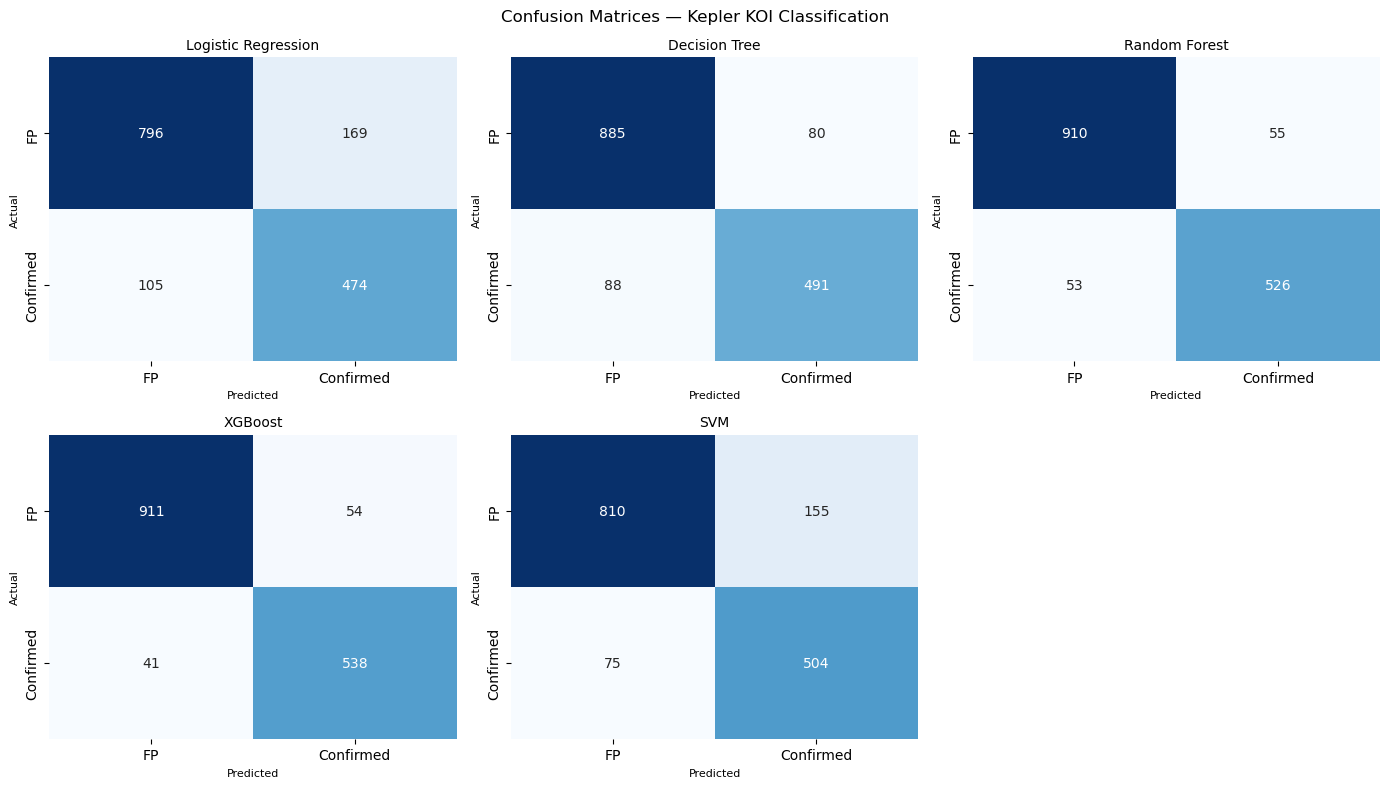

In [10]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[1, 2].set_visible(False)

models_order = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']
positions = [(0,0), (0,1), (0,2), (1,0), (1,1)]

for (row, col), name in zip(positions, models_order):
    model = models[name]
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[row, col],
                xticklabels=['FP', 'Confirmed'],
                yticklabels=['FP', 'Confirmed'],
                cbar=False)

    axes[row, col].set_title(name, fontsize=10)
    axes[row, col].set_xlabel('Predicted', fontsize=8)
    axes[row, col].set_ylabel('Actual', fontsize=8)

plt.suptitle('Confusion Matrices — Kepler KOI Classification', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

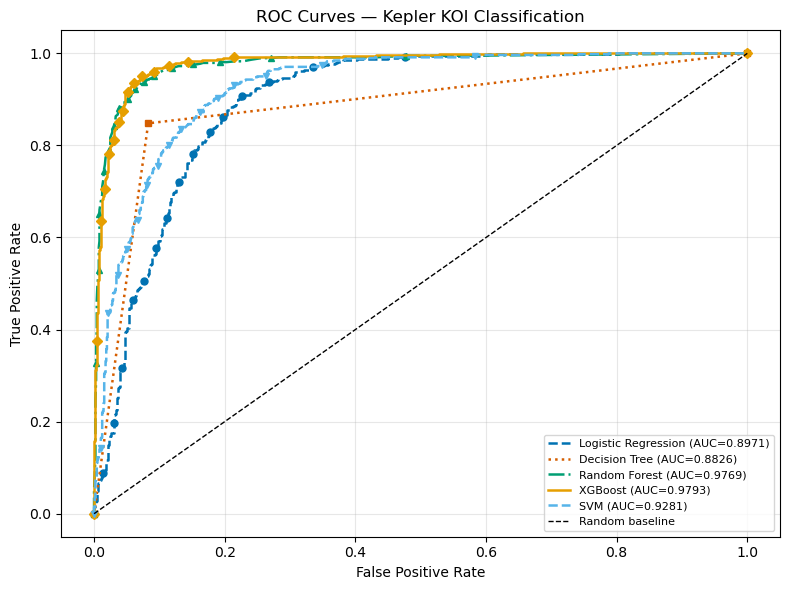

In [11]:
# ROC curves — colorblind-safe palette (Wong 2011) + markers
# Colors: blue, vermillion, bluish-green, orange, sky-blue
WONG = {
    'Logistic Regression': ('#0072B2', 'o', '--'),   # blue, dashed
    'Decision Tree':       ('#D55E00', 's', ':'),    # vermillion, dotted
    'Random Forest':       ('#009E73', '^', '-.'),   # bluish-green, dashdot
    'XGBoost':             ('#E69F00', 'D', '-'),    # orange, solid
    'SVM':                 ('#56B4E9', 'v', '--'),   # sky-blue, dashed
}

fig, ax = plt.subplots(figsize=(8, 6))

for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['ROC AUC']
    color, marker, ls = WONG[name]
    # Plot markers sparsely to avoid clutter
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=1.8,
            label=f'{name} (AUC={auc:.4f})')
    step = max(1, len(fpr)//15)
    ax.plot(fpr[::step], tpr[::step], color=color, marker=marker,
            markersize=5, linestyle='none')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Kepler KOI Classification')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Stability Analysis — Cross-Seed GroupKFold CV

In [12]:
# Cross-seed stability with group-aware CV
# GroupKFold ensures no kepid appears in both train and test folds
# Variance across seeds reflects sensitivity to data partitioning
X_all      = df_model[features].fillna(train_medians).values
y_all      = df_model['target'].values
groups_all = df_model['kepid'].values

seeds = [0, 7, 21, 42, 99]
stability_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost':       XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=RANDOM_STATE),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)),
    ]),
}

print("=" * 55)
print("STABILITY ANALYSIS — ROC AUC across 5 seeds")
print("=" * 55)
print(f"Dataset: N={len(X_all)} labelled objects, 5-fold GroupKFold\n")

stability_results = {}

for name, model in stability_models.items():
    scores = []
    for seed in seeds:
        # Shuffle groups with this seed, then split into 5 folds
        rng = np.random.RandomState(seed)
        unique_groups = np.sort(np.unique(groups_all))  # sorted for cross-execution reproducibility
        shuffled = rng.permutation(unique_groups)
        fold_assignments = {g: i % 5 for i, g in enumerate(shuffled)}
        fold_indices = np.array([fold_assignments[g] for g in groups_all])

        fold_scores = []
        for fold in range(5):
            test_mask  = fold_indices == fold
            train_mask = ~test_mask
            cv_score = roc_auc_score(
                y_all[test_mask],
                model.fit(X_all[train_mask], y_all[train_mask]).predict_proba(X_all[test_mask])[:,1]
            )
            fold_scores.append(cv_score)
        scores.append(np.mean(fold_scores))

    stability_results[name] = scores
    print(f"{name}:")
    print(f"  Scores: {[round(s, 4) for s in scores]}")
    print(f"  Mean:   {np.mean(scores):.4f}")
    print(f"  Std:    {np.std(scores):.4f}")
    print()


STABILITY ANALYSIS — ROC AUC across 5 seeds
Dataset: N=7585 labelled objects, 5-fold GroupKFold

Logistic Regression:
  Scores: [np.float64(0.8951), np.float64(0.8961), np.float64(0.8966), np.float64(0.8963), np.float64(0.8961)]
  Mean:   0.8960
  Std:    0.0005

Decision Tree:
  Scores: [np.float64(0.8722), np.float64(0.8665), np.float64(0.8679), np.float64(0.8709), np.float64(0.8653)]
  Mean:   0.8685
  Std:    0.0026

Random Forest:
  Scores: [np.float64(0.9726), np.float64(0.9727), np.float64(0.9724), np.float64(0.9729), np.float64(0.9727)]
  Mean:   0.9726
  Std:    0.0002

XGBoost:
  Scores: [np.float64(0.9771), np.float64(0.9769), np.float64(0.9773), np.float64(0.9763), np.float64(0.9776)]
  Mean:   0.9771
  Std:    0.0004

SVM:
  Scores: [np.float64(0.9226), np.float64(0.9224), np.float64(0.9227), np.float64(0.9226), np.float64(0.9225)]
  Mean:   0.9226
  Std:    0.0001



In [13]:
stability_df = pd.DataFrame({
    name: {
        'Mean ROC AUC': round(np.mean(scores), 4),
        'Std':          round(np.std(scores), 4),
        'Min':          round(min(scores), 4),
        'Max':          round(max(scores), 4),
    }
    for name, scores in stability_results.items()
}).T

print("=" * 55)
print("STABILITY ANALYSIS — ROC AUC across 5 seeds")
print("=" * 55)
print(stability_df.to_string())

STABILITY ANALYSIS — ROC AUC across 5 seeds
                     Mean ROC AUC     Std     Min     Max
Logistic Regression        0.8960  0.0005  0.8951  0.8966
Decision Tree              0.8685  0.0026  0.8653  0.8722
Random Forest              0.9726  0.0002  0.9724  0.9729
XGBoost                    0.9771  0.0004  0.9763  0.9776
SVM                        0.9226  0.0001  0.9224  0.9227


## 8. Feature Importance

In [14]:
# Impurity-based importance (Random Forest)
rf_model = models['Random Forest']

impurity_imp = pd.DataFrame({
    'feature': features,
    'impurity': rf_model.feature_importances_
}).sort_values('impurity', ascending=False)

print("=== Impurity-based Feature Importance (Random Forest) ===\n")
print(impurity_imp.to_string(index=False))

=== Impurity-based Feature Importance (Random Forest) ===

      feature  impurity
     koi_prad  0.167072
koi_model_snr  0.146123
   koi_period  0.112628
   koi_impact  0.095093
      koi_teq  0.083812
    koi_insol  0.081006
 koi_duration  0.077156
    koi_depth  0.076994
    koi_steff  0.047792
     koi_srad  0.045064
    koi_slogg  0.039770
   koi_kepmag  0.027491


In [15]:
# Permutation importance (more reliable for high-cardinality features)
result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='roc_auc'
)

perm_imp = pd.DataFrame({
    'feature': features,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

print("=== Permutation Importance (Random Forest, 10 repeats) ===\n")
print(perm_imp.to_string(index=False))

=== Permutation Importance (Random Forest, 10 repeats) ===

      feature  importance_mean  importance_std
     koi_prad         0.083460        0.006298
koi_model_snr         0.052468        0.001529
 koi_duration         0.020420        0.002094
   koi_impact         0.020302        0.001692
   koi_period         0.013208        0.001693
    koi_depth         0.007799        0.001156
    koi_insol         0.007675        0.001833
    koi_steff         0.005865        0.000766
      koi_teq         0.005279        0.001805
     koi_srad         0.004169        0.000542
    koi_slogg         0.003589        0.000392
   koi_kepmag         0.000144        0.000658


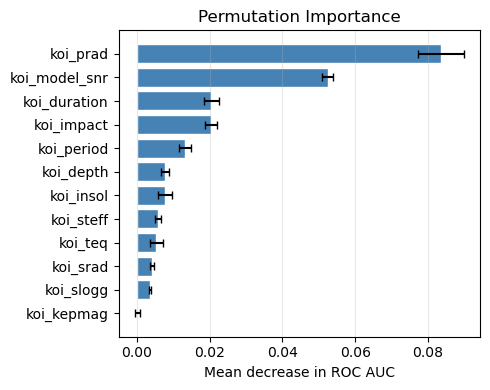

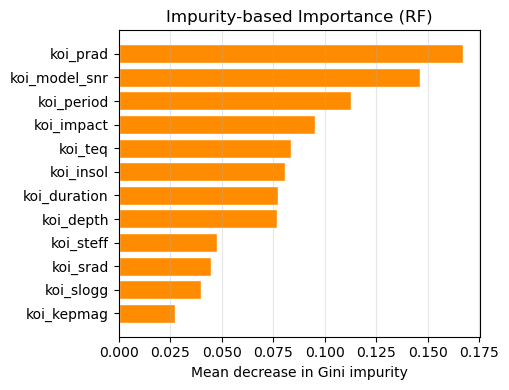

Saved both figures.


In [16]:
# Plot both importance methods side by side
fig, ax = plt.subplots(figsize=(5, 4))
comp_perm = perm_imp.sort_values('importance_mean', ascending=True)
ax.barh(comp_perm['feature'], comp_perm['importance_mean'],
        xerr=comp_perm['importance_std'],
        color='steelblue', edgecolor='white', capsize=3)
ax.set_xlabel('Mean decrease in ROC AUC')
ax.set_title('Permutation Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance_permutation.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
comp_imp = impurity_imp.sort_values('impurity', ascending=True)
ax.barh(comp_imp['feature'], comp_imp['impurity'],
        color='darkorange', edgecolor='white')
ax.set_xlabel('Mean decrease in Gini impurity')
ax.set_title('Impurity-based Importance (RF)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance_impurity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved both figures.")

## 9. Feature Correlation and Multicollinearity (VIF)

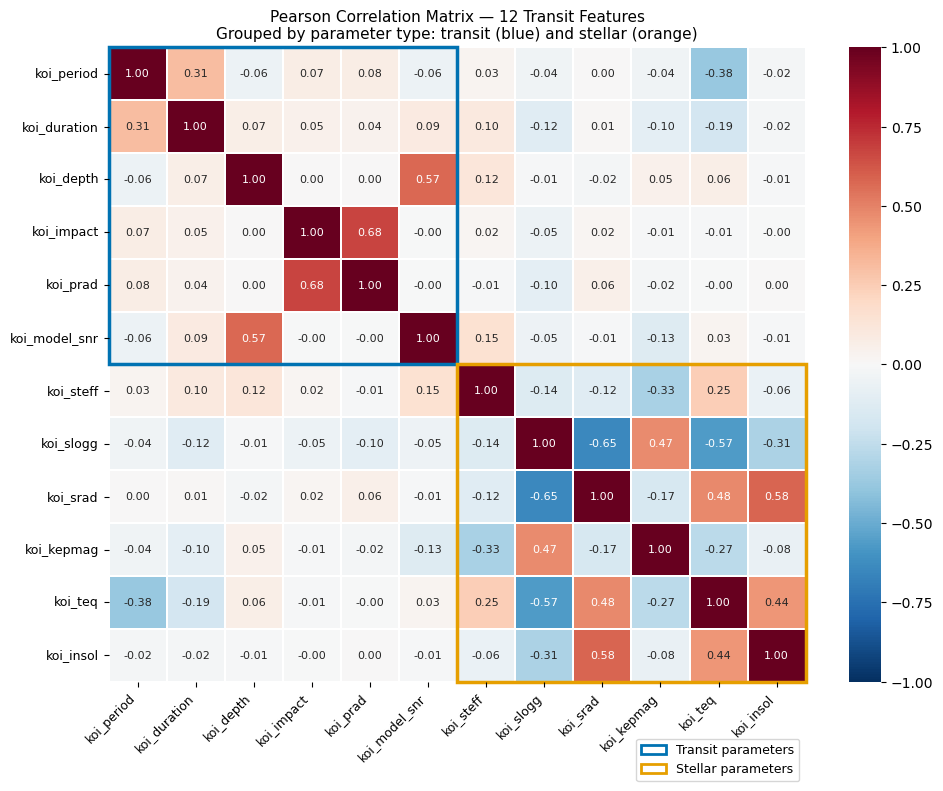

Transit block: low internal correlation (mostly blue)
Stellar block: high internal correlation (red) → multicollinearity

Mean |corr| within transit block: 0.139
Mean |corr| within stellar block: 0.327


In [17]:
# Pearson correlation matrix — grouped by parameter type
# Transit parameters first, stellar parameters second
# This ordering highlights the multicollinearity block among stellar parameters

transit_features = [
    'koi_period',
    'koi_duration', 
    'koi_depth',
    'koi_impact',
    'koi_prad',
    'koi_model_snr',
]

stellar_features = [
    'koi_steff',
    'koi_slogg',
    'koi_srad',
    'koi_kepmag',
    'koi_teq',
    'koi_insol',
]

ordered_features = transit_features + stellar_features

corr = df_model[ordered_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.3,
    linecolor='white',
    annot_kws={'size': 8},
)

# Border around transit parameter block (top-left 6x6)
ax.add_patch(plt.Rectangle(
    (0, 0), len(transit_features), len(transit_features),
    fill=False, edgecolor='#0072B2', linewidth=2.5, clip_on=False
))

# Border around stellar parameter block (bottom-right 6x6)
ax.add_patch(plt.Rectangle(
    (len(transit_features), len(transit_features)),
    len(stellar_features), len(stellar_features),
    fill=False, edgecolor='#E69F00', linewidth=2.5, clip_on=False
))

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(edgecolor='#0072B2', facecolor='none', linewidth=2,
          label='Transit parameters'),
    Patch(edgecolor='#E69F00', facecolor='none', linewidth=2,
          label='Stellar parameters'),
]
ax.legend(handles=legend, loc='upper right',
          bbox_to_anchor=(1.0, -0.08), fontsize=9)

ax.set_title(
    'Pearson Correlation Matrix — 12 Transit Features\n'
    'Grouped by parameter type: transit (blue) and stellar (orange)',
    fontsize=11
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Transit block: low internal correlation (mostly blue)")
print("Stellar block: high internal correlation (red) → multicollinearity")
print(f"\nMean |corr| within transit block: "
      f"{corr.loc[transit_features, transit_features].abs().values[~np.eye(6, dtype=bool)].mean():.3f}")
print(f"Mean |corr| within stellar block: "
      f"{corr.loc[stellar_features, stellar_features].abs().values[~np.eye(6, dtype=bool)].mean():.3f}")

In [18]:
# Variance Inflation Factor (VIF) — quantifies multicollinearity
# High VIF indicates unstable coefficient estimates in linear models
X_vif = X_train.copy()
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]
print("=== Variance Inflation Factors ===\n")
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

=== Variance Inflation Factors ===

      Feature        VIF
    koi_slogg 168.022943
   koi_kepmag 131.132317
    koi_steff  54.682229
      koi_teq   6.307894
     koi_srad   2.260152
   koi_impact   1.979205
 koi_duration   1.920969
     koi_prad   1.897283
koi_model_snr   1.737410
    koi_insol   1.696957
   koi_period   1.685466
    koi_depth   1.676560


## 10. IMDA — Step 1: Voting Analysis

**Inter-Model Disagreement Analysis (IMDA)** is a three-step model-agnostic diagnostic protocol:

- **Step 1 — Voting Analysis**: each model's score is thresholded at 0.5 → binary vote; votes aggregated into per-candidate consensus (0–5)
- **Step 2 — Pairwise Consistency Analysis**: pairwise agreement between all model pairs → identifies algorithmic groupings
- **Step 3 — Grey Zone Characterisation**: candidates with 2–3 votes characterised by physical parameters

In [19]:
# Apply all five models to 1979 unclassified CANDIDATE objects
df_original = pd.read_csv('cumulative.csv', comment='#')
df_candidates = df_original[df_original['koi_disposition'] == 'CANDIDATE'][features].copy()

# Leakage-aware imputation: apply train-set medians (not candidate-specific medians)
# This mirrors the imputation applied to the test set during training
df_candidates = df_candidates.fillna(train_medians)

print(f"Candidates for analysis: {len(df_candidates)}\n")

# Scaled version for LR and SVM
X_candidates = df_candidates[features]
X_candidates_scaled = scaler.transform(X_candidates)

# Model scores for each candidate
df_candidates['prob_LR']  = models['Logistic Regression'].predict_proba(X_candidates_scaled)[:, 1]
df_candidates['prob_DT']  = models['Decision Tree'].predict_proba(X_candidates)[:, 1]
df_candidates['prob_RF']  = models['Random Forest'].predict_proba(X_candidates)[:, 1]
df_candidates['prob_XGB'] = models['XGBoost'].predict_proba(X_candidates)[:, 1]
df_candidates['prob_SVM'] = models['SVM'].predict_proba(X_candidates_scaled)[:, 1]

prob_cols = ['prob_LR', 'prob_DT', 'prob_RF', 'prob_XGB', 'prob_SVM']

# Binary predictions at threshold 0.5 (symmetric decision boundary on score scale)
for col in prob_cols:
    df_candidates[col.replace('prob_', 'pred_')] = (df_candidates[col] >= 0.5).astype(int)

pred_cols = ['pred_LR', 'pred_DT', 'pred_RF', 'pred_XGB', 'pred_SVM']

# Vote count: number of models voting "planet"
df_candidates['votes_planet'] = df_candidates[pred_cols].sum(axis=1)

total = len(df_candidates)
all_agree_planet  = df_candidates[df_candidates['votes_planet'] == 5]
all_agree_not     = df_candidates[df_candidates['votes_planet'] == 0]
majority_planet   = df_candidates[df_candidates['votes_planet'] >= 3]
full_disagreement = df_candidates[df_candidates['votes_planet'].isin([2, 3])]

print("=" * 55)
print("IMDA STEP 1 — Voting Distribution (N=1979 candidates)")
print("=" * 55)
print(f"Total candidates:                     {total}")
print(f"All 5 vote planet:                    {len(all_agree_planet)} ({len(all_agree_planet)/total*100:.1f}%)")
print(f"All 5 vote not planet:                {len(all_agree_not)} ({len(all_agree_not)/total*100:.1f}%)")
print(f"Majority (3+) vote planet:            {len(majority_planet)} ({len(majority_planet)/total*100:.1f}%)")
print(f"Maximum disagreement (2 vs 3):        {len(full_disagreement)} ({len(full_disagreement)/total*100:.1f}%)")
print(f"\nFull consensus (0 or 5):              {(len(all_agree_planet)+len(all_agree_not))/total*100:.1f}%")
print(f"Any disagreement (votes 1-4):         {total - len(all_agree_planet) - len(all_agree_not)} ({(total - len(all_agree_planet) - len(all_agree_not))/total*100:.1f}%)")

Candidates for analysis: 1979

IMDA STEP 1 — Voting Distribution (N=1979 candidates)
Total candidates:                     1979
All 5 vote planet:                    285 (14.4%)
All 5 vote not planet:                619 (31.3%)
Majority (3+) vote planet:            628 (31.7%)
Maximum disagreement (2 vs 3):        696 (35.2%)

Full consensus (0 or 5):              45.7%
Any disagreement (votes 1-4):         1075 (54.3%)


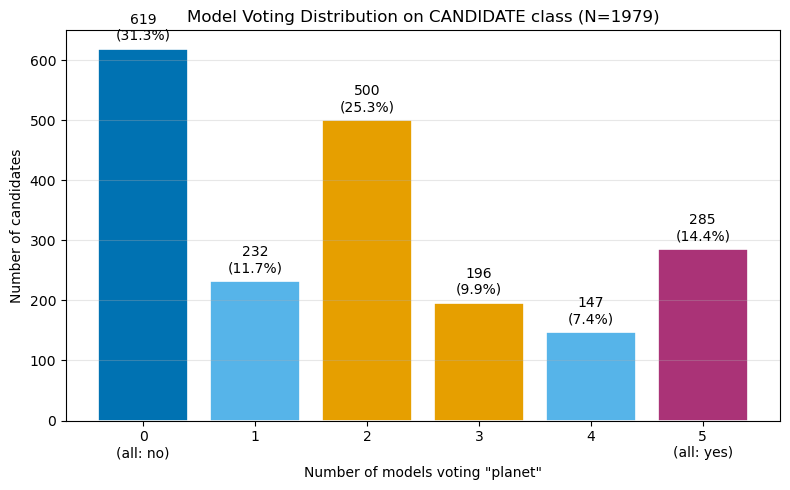

In [20]:
# Voting distribution plot
vote_dist = df_candidates['votes_planet'].value_counts().sort_index()

# Color by zone: All NO=blue, ambiguous=orange, All YES=purple (Wong-safe)
bar_colors = {0: '#0072B2', 1: '#56B4E9', 2: '#E69F00',
              3: '#E69F00', 4: '#56B4E9', 5: '#AA3377'}
colors_list = [bar_colors[v] for v in vote_dist.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(vote_dist.index, vote_dist.values,
              color=colors_list, edgecolor='white', linewidth=1.2)

for bar, (votes, count) in zip(bars, vote_dist.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{count}\n({count/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Number of models voting "planet"')
ax.set_ylabel('Number of candidates')
ax.set_title('Model Voting Distribution on CANDIDATE class (N=1979)')
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['0\n(all: no)', '1', '2', '3', '4', '5\n(all: yes)'])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('candidate_voting.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. IMDA — Step 2: Pairwise Consistency Analysis

In [21]:
# Pairwise consistency between all model pairs
# Grouped by decision boundary type: tree-based vs linear/kernel
model_names_grouped = ['RF', 'XGB', 'DT', 'LR', 'SVM']
pred_cols_grouped   = ['pred_RF', 'pred_XGB', 'pred_DT', 'pred_LR', 'pred_SVM']

consistency_grouped = pd.DataFrame(index=model_names_grouped,
                                   columns=model_names_grouped, dtype=float)

for m1, c1 in zip(model_names_grouped, pred_cols_grouped):
    for m2, c2 in zip(model_names_grouped, pred_cols_grouped):
        agree = (df_candidates[c1] == df_candidates[c2]).sum()
        consistency_grouped.loc[m1, m2] = round(agree / total * 100, 1)

print("=== IMDA Step 2: Pairwise Consistency on CANDIDATE objects (%) ===\n")
print(consistency_grouped.to_string())

=== IMDA Step 2: Pairwise Consistency on CANDIDATE objects (%) ===

        RF    XGB     DT     LR    SVM
RF   100.0   91.3   82.0   58.9   63.5
XGB   91.3  100.0   82.1   59.4   64.6
DT    82.0   82.1  100.0   59.0   62.9
LR    58.9   59.4   59.0  100.0   88.8
SVM   63.5   64.6   62.9   88.8  100.0


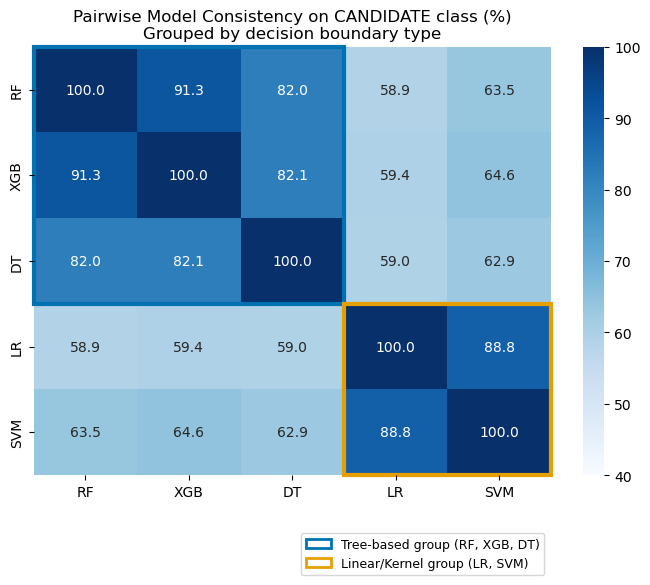

In [22]:
# Pairwise consistency heatmap — colorblind-safe borders (Wong 2011)
# Tree-based: blue (#0072B2), Linear/kernel: orange (#E69F00)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(consistency_grouped.astype(float),
            annot=True, fmt='.1f', cmap='Blues',
            ax=ax, vmin=40, vmax=100,
            xticklabels=model_names_grouped,
            yticklabels=model_names_grouped)

# Tree-based group border — blue
ax.add_patch(plt.Rectangle((0, 0), 3, 3, fill=False,
                             edgecolor='#0072B2', linewidth=3, clip_on=False))

# Linear/kernel group border — orange
ax.add_patch(plt.Rectangle((3, 3), 2, 2, fill=False,
                             edgecolor='#E69F00', linewidth=3, clip_on=False))

from matplotlib.patches import Patch
legend = [
    Patch(edgecolor='#0072B2', facecolor='none', linewidth=2,
          label='Tree-based group (RF, XGB, DT)'),
    Patch(edgecolor='#E69F00', facecolor='none', linewidth=2,
          label='Linear/Kernel group (LR, SVM)'),
]
ax.legend(handles=legend, loc='upper right',
          bbox_to_anchor=(1.0, -0.12), fontsize=9)

ax.set_title('Pairwise Model Consistency on CANDIDATE class (%)\nGrouped by decision boundary type')
plt.tight_layout()
plt.savefig('pairwise_consistency_grouped.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Disagreement Patterns — Section 12b
# Decompose vote=1 and vote=4 cases by which model(s) cast the minority vote
# This verifies the claim about SVM being the dominant single-model dissenter

vote1 = df_candidates[df_candidates['votes_planet'] == 1].copy()
vote4 = df_candidates[df_candidates['votes_planet'] == 4].copy()

print(f"Vote=1 candidates (exactly one model says planet): {len(vote1)}")
print(f"Vote=4 candidates (exactly one model says not-planet): {len(vote4)}")
print()

# For vote=1: which single model is the affirmative voter?
print("=== Vote=1: Which model is the sole 'planet' voter? ===")
for col, name in zip(pred_cols, ['LR','DT','RF','XGB','SVM']):
    n = (vote1[col] == 1).sum()
    pct = n / len(df_candidates) * 100
    print(f"  {name}: {n} candidates ({pct:.1f}% of all {len(df_candidates)})")

print()

# For vote=4: which single model dissents (votes 0)?
print("=== Vote=4: Which model is the sole 'not planet' voter? ===")
for col, name in zip(pred_cols, ['LR','DT','RF','XGB','SVM']):
    n = (vote4[col] == 0).sum()
    pct = n / len(df_candidates) * 100
    print(f"  {name}: {n} candidates ({pct:.1f}% of all {len(df_candidates)})")

print()
print("=== Summary: all vote counts ===")
print(df_candidates['votes_planet'].value_counts().sort_index())
print()
total_disagree = len(df_candidates) - len(all_agree_planet) - len(all_agree_not)
print(f"Total with any disagreement (votes 1-4): {total_disagree} ({total_disagree/len(df_candidates)*100:.1f}%)")

Vote=1 candidates (exactly one model says planet): 232
Vote=4 candidates (exactly one model says not-planet): 147

=== Vote=1: Which model is the sole 'planet' voter? ===
  LR: 109 candidates (5.5% of all 1979)
  DT: 58 candidates (2.9% of all 1979)
  RF: 6 candidates (0.3% of all 1979)
  XGB: 22 candidates (1.1% of all 1979)
  SVM: 37 candidates (1.9% of all 1979)

=== Vote=4: Which model is the sole 'not planet' voter? ===
  LR: 21 candidates (1.1% of all 1979)
  DT: 68 candidates (3.4% of all 1979)
  RF: 36 candidates (1.8% of all 1979)
  XGB: 14 candidates (0.7% of all 1979)
  SVM: 8 candidates (0.4% of all 1979)

=== Summary: all vote counts ===
votes_planet
0    619
1    232
2    500
3    196
4    147
5    285
Name: count, dtype: int64

Total with any disagreement (votes 1-4): 1075 (54.3%)


## 12. IMDA — Step 3: Grey Zone Characterisation

In [24]:
# Assign voting zones to all candidates
# Grey zone: 2-3 votes (maximum inter-model disagreement)
df_candidates['zone'] = df_candidates['votes_planet'].map({
    0: 'All NO',
    1: 'Grey',
    2: 'Grey',
    3: 'Grey',
    4: 'Majority YES',
    5: 'All YES'
})

all_yes = df_candidates[df_candidates['votes_planet'] == 5]
all_no  = df_candidates[df_candidates['votes_planet'] == 0]
grey    = df_candidates[df_candidates['zone'] == 'Grey']

key_features = ['koi_prad', 'koi_period', 'koi_model_snr',
                'koi_impact', 'koi_depth', 'koi_duration']

comparison = pd.DataFrame({
    'All YES (5/5)':     all_yes[key_features].mean(),
    'Grey Zone (2-3/5)': grey[key_features].mean(),
    'All NO (0/5)':      all_no[key_features].mean(),
}).round(3)

print("=" * 55)
print("IMDA STEP 3 — Physical Parameters by Voting Zone")
print("=" * 55)
print(comparison.to_string())

IMDA STEP 3 — Physical Parameters by Voting Zone
               All YES (5/5)  Grey Zone (2-3/5)  All NO (0/5)
koi_prad               2.226              4.293       288.957
koi_period            29.603            199.109       217.078
koi_model_snr         26.076             27.706        37.335
koi_impact             0.394              0.439         1.132
koi_depth            681.885           1010.443      2205.242
koi_duration           4.390              4.445         7.132


In [25]:
# Median / IQR table for grey zone
groups = {
    'All YES':   df_candidates[df_candidates['votes_planet'] == 5],
    'Grey Zone': df_candidates[(df_candidates['votes_planet'] == 2) | (df_candidates['votes_planet'] == 3)],
    'All NO':    df_candidates[df_candidates['votes_planet'] == 0],
}

params = ['koi_prad', 'koi_period', 'koi_model_snr',
          'koi_impact', 'koi_depth', 'koi_duration']

rows = []
for param in params:
    row = {'Parameter': param}
    for gname, gdf in groups.items():
        med = gdf[param].median()
        q1  = gdf[param].quantile(0.25)
        q3  = gdf[param].quantile(0.75)
        row[gname] = f'{med:.2f} [{q1:.2f}-{q3:.2f}]'
    rows.append(row)

pd.DataFrame(rows).set_index('Parameter')

,All YES,Grey Zone,All NO
Parameter,,,
koi_prad,1.83 [1.32-2.52],1.39 [1.01-2.21],2.44 [1.54-4.41]
koi_period,16.48 [7.41-36.77],14.15 [6.68-40.14],205.41 [4.09-371.93]
koi_model_snr,14.50 [12.70-21.00],9.90 [8.30-11.80],11.00 [8.60-19.40]
koi_impact,0.32 [0.08-0.68],0.34 [0.13-0.65],0.47 [0.18-0.73]
koi_depth,283.20 [130.70-605.80],195.10 [90.67-392.77],422.90 [163.70-674.60]
koi_duration,3.67 [2.51-5.51],3.23 [2.16-5.08],4.47 [2.52-10.41]


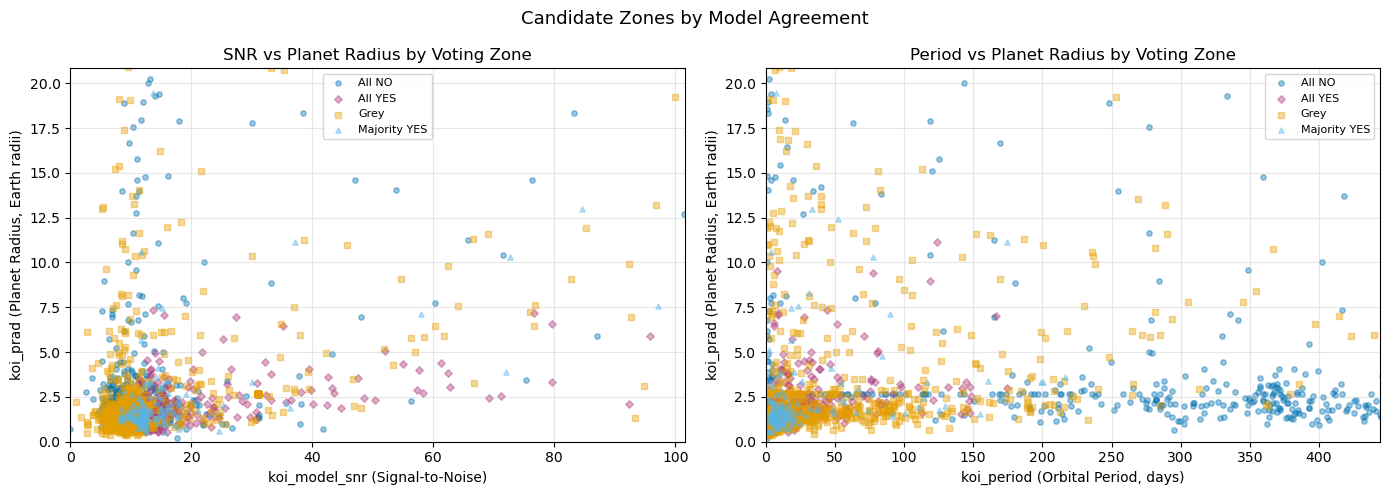

In [26]:
# Scatter plots: voting zones — colorblind-safe palette (Wong 2011)
snr_max  = df_candidates['koi_model_snr'].quantile(0.95)
prad_max = df_candidates['koi_prad'].quantile(0.95)
per_max  = df_candidates['koi_period'].quantile(0.95)

# Wong-safe: blue=All NO, orange=Grey, sky-blue=Majority YES, purple=All YES
colors = {
    'All NO':       '#0072B2',  # blue
    'Grey':         '#E69F00',  # orange
    'Majority YES': '#56B4E9',  # sky-blue
    'All YES':      '#AA3377',  # purple
}
markers = {
    'All NO': 'o', 'Grey': 's', 'Majority YES': '^', 'All YES': 'D'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for zone, group in df_candidates.groupby('zone'):
    axes[0].scatter(group['koi_model_snr'], group['koi_prad'],
                    c=colors[zone], marker=markers[zone],
                    label=zone, alpha=0.4, s=15)
    axes[1].scatter(group['koi_period'], group['koi_prad'],
                    c=colors[zone], marker=markers[zone],
                    label=zone, alpha=0.4, s=15)

axes[0].set_xlim(0, snr_max); axes[0].set_ylim(0, prad_max)
axes[1].set_xlim(0, per_max); axes[1].set_ylim(0, prad_max)

axes[0].set_xlabel('koi_model_snr (Signal-to-Noise)')
axes[0].set_ylabel('koi_prad (Planet Radius, Earth radii)')
axes[0].set_title('SNR vs Planet Radius by Voting Zone')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('koi_period (Orbital Period, days)')
axes[1].set_ylabel('koi_prad (Planet Radius, Earth radii)')
axes[1].set_title('Period vs Planet Radius by Voting Zone')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('Candidate Zones by Model Agreement', fontsize=13)
plt.tight_layout()
plt.savefig('candidate_zones_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

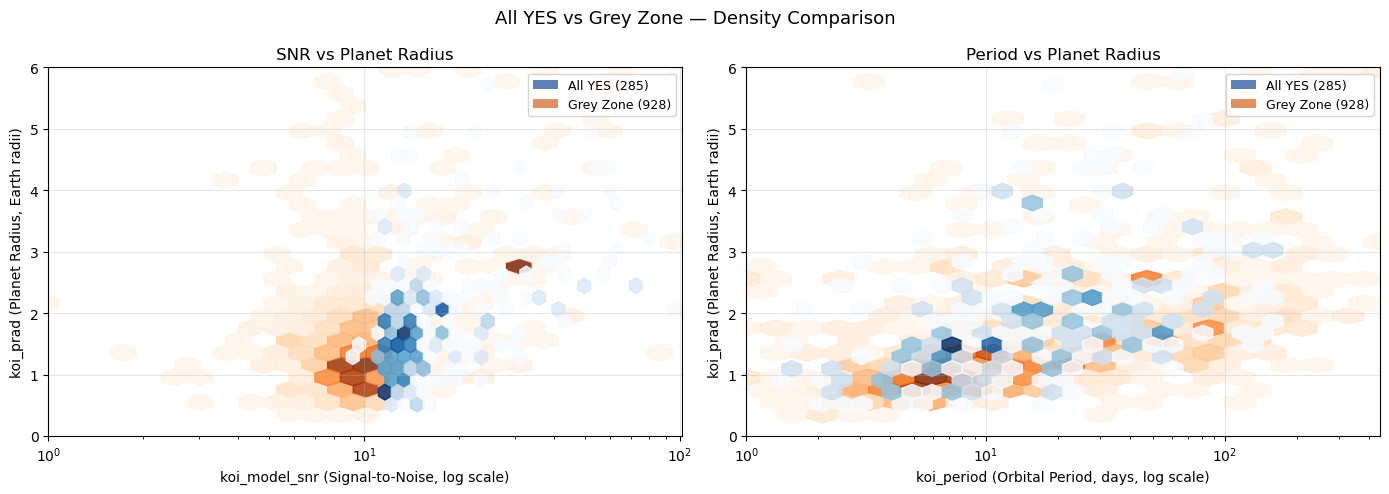

In [27]:
# Hexbin density comparison: All YES vs Grey Zone
# Colorblind-safe: Blues (All YES) vs Oranges (Grey Zone)
prad_plot_max = 6

ay  = all_yes[(all_yes['koi_model_snr'] < snr_max) & (all_yes['koi_prad'] < prad_plot_max)]
gy  = grey[(grey['koi_model_snr'] < snr_max) & (grey['koi_prad'] < prad_plot_max)]
ay2 = all_yes[(all_yes['koi_period'] < per_max) & (all_yes['koi_prad'] < prad_plot_max)]
gy2 = grey[(grey['koi_period'] < per_max) & (grey['koi_prad'] < prad_plot_max)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grey zone first (background), All YES on top
axes[0].hexbin(gy['koi_model_snr'], gy['koi_prad'],
               gridsize=25, cmap='Oranges', mincnt=1, alpha=0.85, xscale='log')
axes[0].hexbin(ay['koi_model_snr'], ay['koi_prad'],
               gridsize=25, cmap='Blues', mincnt=1, alpha=0.85, xscale='log')
axes[0].set_xlim(1, snr_max); axes[0].set_ylim(0, prad_plot_max)
axes[0].set_xscale('log')
axes[0].set_xlabel('koi_model_snr (Signal-to-Noise, log scale)')
axes[0].set_ylabel('koi_prad (Planet Radius, Earth radii)')
axes[0].set_title('SNR vs Planet Radius')
axes[0].grid(True, alpha=0.3)

axes[1].hexbin(gy2['koi_period'], gy2['koi_prad'],
               gridsize=25, cmap='Oranges', mincnt=1, alpha=0.85, xscale='log')
axes[1].hexbin(ay2['koi_period'], ay2['koi_prad'],
               gridsize=25, cmap='Blues', mincnt=1, alpha=0.85, xscale='log')
axes[1].set_xlim(1, per_max); axes[1].set_ylim(0, prad_plot_max)
axes[1].set_xscale('log')
axes[1].set_xlabel('koi_period (Orbital Period, days, log scale)')
axes[1].set_ylabel('koi_prad (Planet Radius, Earth radii)')
axes[1].set_title('Period vs Planet Radius')
axes[1].grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend = [
    Patch(facecolor='#4C72B0', alpha=0.9, label=f'All YES ({len(all_yes)})'),
    Patch(facecolor='#DD8452', alpha=0.9, label=f'Grey Zone ({len(grey)})'),
]
for ax in axes:
    ax.legend(handles=legend, fontsize=9)

plt.suptitle('All YES vs Grey Zone — Density Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('grey_zone_hexbin.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Grey Zone — Bin-Level Analysis by Physical Parameters

In [28]:
# Grey zone and All-NO rate by orbital period bins
# Extended Table 9: includes All-NO rate to verify "68-93%" claim in text

bins   = [0, 10, 50, 100, 200, 300, np.inf]
labels = ['0–10', '10–50', '50–100', '100–200', '200–300', '300+']

df_candidates['period_bin'] = pd.cut(
    df_candidates['koi_period'],
    bins=bins, labels=labels, right=False
)

print("=" * 65)
print("GREY ZONE AND ALL-NO RATE BY ORBITAL PERIOD")
print("=" * 65)
print(f"{'Bin (days)':<12} {'N':>5} {'All NO':>7} {'Grey':>6} {'All YES':>8} {'All NO%':>9} {'Grey%':>7}")
print("-" * 65)

period_rows = []
for label in labels:
    mask    = df_candidates['period_bin'] == label
    subset  = df_candidates[mask]
    n       = len(subset)
    all_no  = (subset['votes_planet'] == 0).sum()
    grey    = ((subset['votes_planet'] >= 2) & (subset['votes_planet'] <= 3)).sum()
    all_yes = (subset['votes_planet'] == 5).sum()
    all_no_pct = all_no / n * 100 if n > 0 else 0
    grey_pct   = grey   / n * 100 if n > 0 else 0
    period_rows.append((label, n, all_no, grey, all_yes, all_no_pct, grey_pct))
    print(f"{label:<12} {n:>5} {all_no:>7} {grey:>6} {all_yes:>8} "
          f"{all_no_pct:>8.1f}% {grey_pct:>6.1f}%")

total_binned = sum(r[1] for r in period_rows)
print()
print(f"Total binned: {total_binned} / {len(df_candidates)} candidates")
if total_binned < len(df_candidates):
    print(f"Note: {len(df_candidates) - total_binned} candidates have missing koi_period values")

print()
print("All-NO % in long-period bins (≥200 days):")
for label, n, all_no, grey, all_yes, all_no_pct, grey_pct in period_rows:
    if label in ['200–300', '300+']:
        print(f"  {label}: {all_no_pct:.1f}% All-NO (N={n})")


GREY ZONE AND ALL-NO RATE BY ORBITAL PERIOD
Bin (days)       N  All NO   Grey  All YES   All NO%   Grey%
-----------------------------------------------------------------
0–10           702     190    269       94     27.1%   38.3%
10–50          554      33    281      140      6.0%   50.7%
50–100         184      28     84       35     15.2%   45.7%
100–200        161      56     35       16     34.8%   21.7%
200–300        113      77     15        0     68.1%   13.3%
300+           265     235     12        0     88.7%    4.5%

Total binned: 1979 / 1979 candidates

All-NO % in long-period bins (≥200 days):
  200–300: 68.1% All-NO (N=113)
  300+: 88.7% All-NO (N=265)


In [29]:
# Disagreement rate by multiple physical parameter bins
key_features_bins = {
    'koi_period':    ([0, 10, 50, 100, 200, 300, 500], 'Orbital Period (days)'),
    'koi_model_snr': ([0, 10, 20, 30, 50, 100, 200],   'Signal-to-Noise Ratio'),
    'koi_prad':      ([0, 1, 2, 4, 8, 16, 300],         'Planet Radius (Earth radii)'),
    'koi_impact':    ([0, 0.3, 0.6, 0.9, 1.5],          'Impact Parameter'),
}

print("=== Disagreement Rate by Physical Parameter Bins ===\n")

for feature, (bins, xlabel) in key_features_bins.items():
    df_temp = df_candidates.copy()
    bin_labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]
    df_temp['bin'] = pd.cut(df_temp[feature], bins=bins, labels=bin_labels)

    bin_stats = df_temp.groupby('bin', observed=True).agg(
        total=('votes_planet', 'count'),
        grey_zone=('votes_planet', lambda x: ((x == 2) | (x == 3)).sum()),
        all_yes=('votes_planet', lambda x: (x == 5).sum()),
        all_no=('votes_planet', lambda x: (x == 0).sum()),
    ).reset_index()

    bin_stats['disagreement_rate'] = (bin_stats['grey_zone'] / bin_stats['total'] * 100).round(1)
    bin_stats['consensus_rate']    = ((bin_stats['all_yes'] + bin_stats['all_no']) / bin_stats['total'] * 100).round(1)

    print(f"--- {feature} ---")
    print(bin_stats[['bin', 'total', 'grey_zone', 'all_yes', 'all_no',
                      'disagreement_rate', 'consensus_rate']].to_string(index=False))
    print()

=== Disagreement Rate by Physical Parameter Bins ===

--- koi_period ---
    bin  total  grey_zone  all_yes  all_no  disagreement_rate  consensus_rate
   0-10    702        269       94     190               38.3            40.5
  10-50    554        281      140      33               50.7            31.2
 50-100    184         84       35      28               45.7            34.2
100-200    161         35       16      56               21.7            44.7
200-300    113         15        0      77               13.3            68.1
300-500    199          5        0     183                2.5            92.0

--- koi_model_snr ---
    bin  total  grey_zone  all_yes  all_no  disagreement_rate  consensus_rate
   0-10    731        367        2     243               50.2            33.5
  10-20    828        221      207     222               26.7            51.8
  20-30     86         18       29      21               20.9            58.1
  30-50    171         46       21      80    

## 14. Sensitivity Analysis — Decision Threshold

In [30]:
# Sensitivity of voting distribution to threshold choice
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60]
prob_cols  = ['prob_LR', 'prob_DT', 'prob_RF', 'prob_XGB', 'prob_SVM']

sensitivity_results = []

for t in thresholds:
    votes   = (df_candidates[prob_cols] >= t).sum(axis=1)
    grey    = ((votes >= 2) & (votes <= 3)).sum()
    all_yes = (votes == 5).sum()
    all_no  = (votes == 0).sum()
    total   = len(df_candidates)

    sensitivity_results.append({
        'Threshold': t,
        'All NO (0)':  all_no,
        'Grey (2-3)':  grey,
        'All YES (5)': all_yes,
        'Grey %':      round(grey / total * 100, 1),
        'All YES %':   round(all_yes / total * 100, 1),
        'All NO %':    round(all_no / total * 100, 1),
    })

sens_df = pd.DataFrame(sensitivity_results)
print("=== Sensitivity Analysis: Voting Distribution by Threshold ===\n")
print(sens_df.to_string(index=False))

=== Sensitivity Analysis: Voting Distribution by Threshold ===

 Threshold  All NO (0)  Grey (2-3)  All YES (5)  Grey %  All YES %  All NO %
      0.40         513         736          341    37.2       17.2      25.9
      0.45         558         726          314    36.7       15.9      28.2
      0.50         619         696          285    35.2       14.4      31.3
      0.55         685         668          250    33.8       12.6      34.6
      0.60         753         640          204    32.3       10.3      38.0


## 15. Calibration Diagnostics

CALIBRATION DIAGNOSTICS — Test Set
Model                    Brier     ECE    rECE     MCE     HL p Direction
---------------------------------------------------------------------------
Logistic Regression     0.1241  0.0420  0.0396  0.1136   0.0005 -0.005 (over)
Decision Tree           0.1088  0.0570  0.0997  0.0904   0.0010 +0.090 (under)
Random Forest           0.0539  0.0366  0.0385  0.1200   0.0000 +0.005 (under)
XGBoost                 0.0498  0.0230  0.0136  0.1835   0.0000 -0.001 (over)
SVM                     0.1031  0.0224  0.0166  0.0485   0.3059 -0.002 (over)


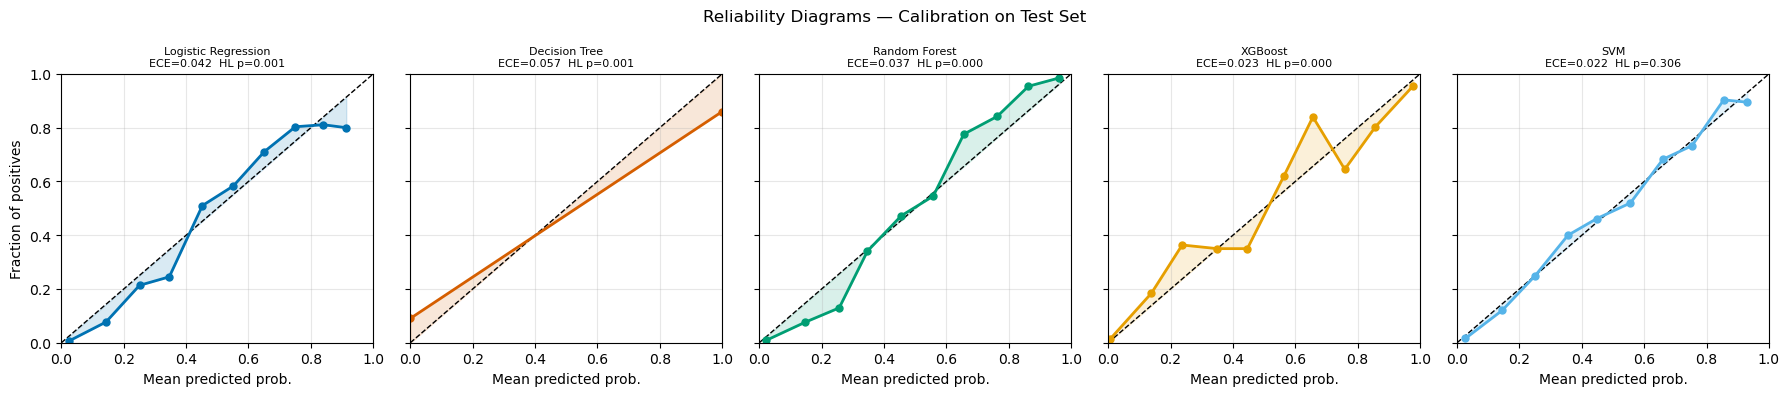


=== Decision: proceed to Platt scaling? ===
Logistic Regression    HL p < 0.05 → statistically miscalibrated
Decision Tree          HL p < 0.05 → statistically miscalibrated
Random Forest          HL p < 0.05 → statistically miscalibrated
XGBoost                MCE > 0.15 → single bin severely miscalibrated | HL p < 0.05 → statistically miscalibrated
SVM                    OK — no action needed


In [31]:
# Calibration Analysis — Section 13 (Extended)
# ECE, MCE, Refined ECE, Hosmer-Lemeshow, direction analysis

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from scipy.stats import chi2

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Standard ECE — equal-width bins."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

def maximum_calibration_error(y_true, y_prob, n_bins=10):
    """MCE — worst single bin deviation."""
    bins = np.linspace(0, 1, n_bins + 1)
    mce = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        mce = max(mce, abs(bin_acc - bin_conf))
    return mce

def refined_ece(y_true, y_prob, n_bins=10):
    """Refined ECE — equal-count bins (adaptive binning)."""
    order = np.argsort(y_prob)
    y_true_s = y_true[order]
    y_prob_s = y_prob[order]
    bins = np.array_split(np.arange(len(y_true)), n_bins)
    ece = 0.0
    for b in bins:
        if len(b) == 0:
            continue
        bin_acc  = y_true_s[b].mean()
        bin_conf = y_prob_s[b].mean()
        ece += len(b) * abs(bin_acc - bin_conf)
    return ece / len(y_true)

def hosmer_lemeshow(y_true, y_prob, n_bins=10):
    """
    Hosmer-Lemeshow goodness-of-fit test.
    H0: model is well-calibrated.
    Returns: chi2 statistic, p-value.
    p > 0.05 → no evidence of miscalibration.
    """
    order = np.argsort(y_prob)
    y_true_s = y_true[order]
    y_prob_s = y_prob[order]
    bins = np.array_split(np.arange(len(y_true)), n_bins)
    hl_stat = 0.0
    for b in bins:
        n     = len(b)
        O_pos = y_true_s[b].sum()
        E_pos = y_prob_s[b].sum()
        O_neg = n - O_pos
        E_neg = n - E_pos
        if E_pos > 0:
            hl_stat += (O_pos - E_pos)**2 / E_pos
        if E_neg > 0:
            hl_stat += (O_neg - E_neg)**2 / E_neg
    p_value = 1 - chi2.cdf(hl_stat, df=n_bins - 2)
    return hl_stat, p_value

def calibration_direction(y_true, y_prob, n_bins=10):
    """
    Mean signed error: positive = underconfident, negative = overconfident.
    """
    bins = np.linspace(0, 1, n_bins + 1)
    signed = 0.0
    total_weight = 0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        signed += mask.sum() * (bin_acc - bin_conf)
        total_weight += mask.sum()
    return signed / total_weight  # positive=underconfident, negative=overconfident

# --- Run diagnostics ---
print("=" * 55)
print("CALIBRATION DIAGNOSTICS — Test Set")
print("=" * 55)
print(f"{'Model':<22} {'Brier':>7} {'ECE':>7} {'rECE':>7} "
      f"{'MCE':>7} {'HL p':>8} {'Direction'}")
print("-" * 75)

calib_data = {}
for name in results:
    y_prob = np.array(results[name]['y_prob'])
    y_true = np.array(y_test)

    bs    = brier_score_loss(y_true, y_prob)
    ece   = expected_calibration_error(y_true, y_prob)
    rece  = refined_ece(y_true, y_prob)
    mce   = maximum_calibration_error(y_true, y_prob)
    hl_s, hl_p = hosmer_lemeshow(y_true, y_prob)
    direction = calibration_direction(y_true, y_prob)
    dir_str = f"+{direction:.3f} (under)" if direction > 0 else f"{direction:.3f} (over)"

    calib_data[name] = {
        'y_prob': y_prob, 'brier': bs, 'ece': ece,
        'rece': rece, 'mce': mce, 'hl_p': hl_p, 'direction': direction
    }
    print(f"{name:<22} {bs:>7.4f} {ece:>7.4f} {rece:>7.4f} "
          f"{mce:>7.4f} {hl_p:>8.4f} {dir_str}")

# --- Reliability diagrams ---
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

WONG = {
    'Logistic Regression': '#0072B2',
    'Decision Tree':       '#D55E00',
    'Random Forest':       '#009E73',
    'XGBoost':             '#E69F00',
    'SVM':                 '#56B4E9',
}

for ax, name in zip(axes, results):
    y_prob = calib_data[name]['y_prob']
    y_true = np.array(y_test)
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.plot(prob_pred, prob_true, color=WONG[name],
            marker='o', markersize=5, linewidth=2)
    ax.fill_between(prob_pred, prob_pred, prob_true,
                    alpha=0.15, color=WONG[name])

    ece = calib_data[name]['ece']
    hl_p = calib_data[name]['hl_p']
    ax.set_title(f"{name}\nECE={ece:.3f}  HL p={hl_p:.3f}", fontsize=8)
    ax.set_xlabel('Mean predicted prob.')
    if ax == axes[0]:
        ax.set_ylabel('Fraction of positives')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle('Reliability Diagrams — Calibration on Test Set', fontsize=12)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Decision ---
print("\n=== Decision: proceed to Platt scaling? ===")
for name, d in calib_data.items():
    flags = []
    if d['ece'] >= 0.10:
        flags.append("ECE > 0.10 → Platt scaling recommended")
    if d['mce'] >= 0.15:
        flags.append("MCE > 0.15 → single bin severely miscalibrated")
    if d['hl_p'] < 0.05:
        flags.append("HL p < 0.05 → statistically miscalibrated")
    status = " | ".join(flags) if flags else "OK — no action needed"
    print(f"{name:<22} {status}")

### XGBoost Per-Bin Analysis

In [32]:
# Per-bin breakdown for XGBoost — identify source of elevated MCE
y_prob = np.array(results['XGBoost']['y_prob'])
y_true = np.array(y_test)
bins = np.linspace(0, 1, 11)
print("XGBoost bin analysis:")
for i in range(10):
    mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
    if mask.sum() == 0:
        continue
    acc  = y_true[mask].mean()
    conf = y_prob[mask].mean()
    print(f"  [{bins[i]:.1f}-{bins[i+1]:.1f}] n={mask.sum():4d} "
          f"conf={conf:.3f} acc={acc:.3f} diff={acc-conf:+.3f}")

XGBoost bin analysis:
  [0.0-0.1] n= 852 conf=0.006 acc=0.014 diff=+0.008
  [0.1-0.2] n=  38 conf=0.139 acc=0.184 diff=+0.046
  [0.2-0.3] n=  22 conf=0.237 acc=0.364 diff=+0.126
  [0.3-0.4] n=  20 conf=0.350 acc=0.350 diff=+0.000
  [0.4-0.5] n=  20 conf=0.446 acc=0.350 diff=-0.096
  [0.5-0.6] n=  21 conf=0.563 acc=0.619 diff=+0.056
  [0.6-0.7] n=  25 conf=0.656 acc=0.840 diff=+0.184
  [0.7-0.8] n=  31 conf=0.759 acc=0.645 diff=-0.113
  [0.8-0.9] n=  56 conf=0.857 acc=0.804 diff=-0.054
  [0.9-1.0] n= 459 conf=0.979 acc=0.956 diff=-0.022


## 16. Statistical Comparison — DeLong Test

In [33]:
# DeLong test — fast O(n log n) implementation
# Sun & Xu (2014), IEEE Signal Processing Letters 21(11), 1389-1393
# doi:10.1109/LSP.2014.2337313
# via MLstatkit: https://github.com/Brritany/MLstatkit

import subprocess
import sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'mlstatkit', '-q'], check=True)

try:
    from mlstatkit import Delong_test
except ModuleNotFoundError:
    from MLstatkit import Delong_test

y_true_arr  = np.array(y_test)
y_score_xgb = np.array(results['XGBoost']['y_prob'])
y_score_rf  = np.array(results['Random Forest']['y_prob'])

z, p, ci_xgb, ci_rf, auc_xgb, auc_rf, info = Delong_test(y_true_arr, y_score_xgb, y_score_rf)

print("=" * 55)
print("STATISTICAL TEST — DeLong: XGBoost vs Random Forest")
print("=" * 55)
print(f"Implementation: Sun & Xu (2014) via MLstatkit\n")
print(f"XGBoost       AUC: {auc_xgb:.4f}  95% CI: [{ci_xgb[0]:.3f}, {ci_xgb[1]:.3f}]")
print(f"Random Forest AUC: {auc_rf:.4f}  95% CI: [{ci_rf[0]:.3f}, {ci_rf[1]:.3f}]")
print(f"Difference:        {auc_xgb - auc_rf:.4f}")
print(f"Z-statistic:       {z:.4f}")
print(f"p-value:           {p:.4f}")
print()
if p < 0.05:
    print(f"→ Statistically significant difference (p = {p:.3f} < 0.05)")
else:
    print(f"→ No statistically significant difference (p = {p:.3f} > 0.05)")
    print("  Both models should be considered equivalent performers")
    print("  on this dataset under the default-hyperparameter protocol.")


STATISTICAL TEST — DeLong: XGBoost vs Random Forest
Implementation: Sun & Xu (2014) via MLstatkit

XGBoost       AUC: 0.9793  95% CI: [0.973, 0.985]
Random Forest AUC: 0.9769  95% CI: [0.970, 0.984]
Difference:        0.0024
Z-statistic:       -1.2202
p-value:           0.2224

→ No statistically significant difference (p = 0.222 > 0.05)
  Both models should be considered equivalent performers
  on this dataset under the default-hyperparameter protocol.
